In [47]:
import json
import numpy as np
from functools import reduce
from tqdm.auto import tqdm
from transformers import AutoTokenizer
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from constants import *
from utils import *

In [48]:
data = np.load("data/data_train_test.npy", allow_pickle=True).item()
predictions = np.load("data/predictions.npy", allow_pickle=True).item()
data.keys(), predictions.keys()

(dict_keys(['Q_train', 'Q_test', 'X_train', 'X_test', 'XOAI_train', 'XOAI_test', 'Y_train', 'Y_test', 'C_train', 'C_test', 'models']),
 dict_keys(['mf_routellm', 'mf_OAI_routellm', 'knn_ours', 'knn_OAI_ours', 'knn_OAI_lamb-0', 'knn_OAI_lamb-1', 'knn_OAI_lamb-2', 'knn_OAI_lamb-3', 'knn_OAI_lamb-4', 'knn_OAI_lamb-5', 'knn_OAI_lamb-6', 'rorf_nd', 'rorf_OAI_nd', 'bert_ours', 'bert_routellm']))

In [60]:
methods1 = ['bert_ours',
            'knn_OAI_ours',
            'mf_OAI_routellm',
            'bert_routellm',
            'rorf_OAI_nd']

methods2 = ['bert_ours',
            'knn_OAI_ours',
            'knn_ours',
            #'knn_lamb-0',
            'knn_OAI_lamb-0',
            #'knn_lamb-1',
            'knn_OAI_lamb-1',
            #'knn_lamb-2',
            'knn_OAI_lamb-2',
            #'knn_lamb-3',
            'knn_OAI_lamb-3',
            #'knn_lamb-4',
            'knn_OAI_lamb-4',
            'knn_OAI_lamb-5',
            'knn_OAI_lamb-6']

labels = {'mf_OAI_routellm':'RouteLLM (MF)',
          'knn_OAI_ours':'CARROT (KNN)',
          'knn_ours':'CARROT (KNN+SBERT)',
          'rorf_OAI_nd':'Not-Diamond RoRF',
          'bert_ours':'CARROT (Roberta)',
          'bert_routellm':'RouteLLM (Roberta)'}

colors = {'mf_OAI_routellm':'blue',
          'knn_ours':'brown',
          'knn_OAI_ours':'red',
          'rorf_OAI_nd':'green',
          'bert_ours':'orange',
          'bert_routellm':'purple'}

In [61]:
Y_test = data['Y_test']
C_test = data['C_test']

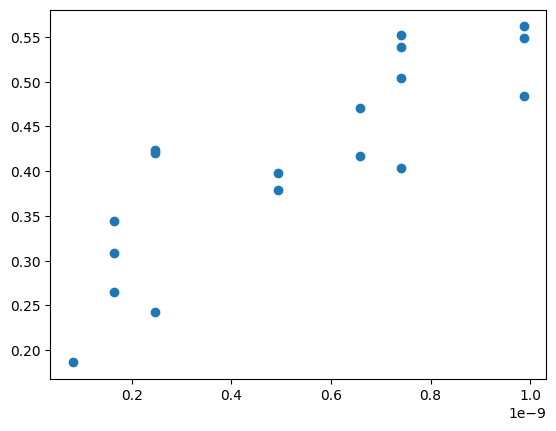

In [62]:
plt.scatter(C_test.mean(0),Y_test.mean(0))

In [63]:
large_model_ind = int(np.argmax(np.array(data['models'])==LARGE_MODEL))
small_model_ind = int(np.argmax(np.array(data['models'])==SMALL_MODEL))

mult=1e6

routers = {}
for model in predictions.keys():
    routers[model] = {}
    if 'routellm' in model or 'rorf' in model:
        routers[model]['cost'], routers[model]['perf'] = route_pairwise(predictions[model].squeeze(), C_test, Y_test, large_model_ind, small_model_ind)
    elif 'lamb-' in model:
        routers[model]['cost'], routers[model]['perf'] = route_lamb(predictions[model], C_test, mult*C_test, Y_test)
    else:    
        routers[model]['cost'], routers[model]['perf'] = route(predictions[model], C_test, mult*C_test, Y_test)

<>:26: SyntaxWarning: invalid escape sequence '\$'
<>:26: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_3365/1214012848.py:26: SyntaxWarning: invalid escape sequence '\$'
  ax.set_xlabel('Cost Per Query, \$')


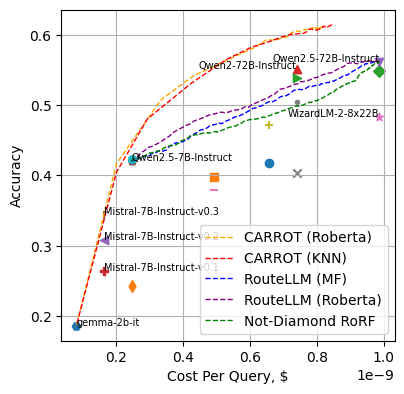

In [64]:
models = data['models']
fig, ax = plt.subplots(1, 1, figsize = (4.3, 4.3))

markers = ['o', 's', 'D', '^', 'v', 'p', '*', 'x', '+', 'h', 'H', 'd', '>', 'P', '<', '|', '_', '.', ',', '1']

for method in methods1:
    if 'lamb-' in method:
        if method.split('lamb-')[1]=='0':
            label = 'ERM router'
        else:
            label = ''
        ax.scatter(routers[method]['cost'], routers[method]['perf'], marker = markers[13], c='black', label = label)
    else:
        ax.errorbar(routers[method]['cost'], routers[method]['perf'], c=colors[method],
        linestyle='--', linewidth=1, alpha = 1, label = labels[method])

for i, txt in enumerate(models):

    x, y = C_test[:,i].mean(0), Y_test[:,i].mean(0)
    ax.scatter([x], [y], marker = markers[i])
    if i in set([3,4,6]):
        ax.annotate(models[i].split('/')[1], (x, y), size=7, horizontalalignment='right')
    if i in set([5,10,13,14,15]):
        ax.annotate(models[i].split('/')[1], (x, y), size=7)

ax.set_xlabel('Cost Per Query, \$')
ax.set_ylabel('Accuracy')
#ax.set_title('Open LLM Leaderboard v2')
# ax.plot(cost_router.mean(axis = 0), correctness_router.mean(axis = 0), linestyle='-', linewidth=2, label='router', alpha = 0.3)
ax.legend()
ax.grid(True)
plt.savefig(f'plots/hf-leaderboard1.pdf', bbox_inches='tight', dpi=400, transparent=False)
plt.show()

<>:26: SyntaxWarning: invalid escape sequence '\$'
<>:26: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_3365/2825496857.py:26: SyntaxWarning: invalid escape sequence '\$'
  ax.set_xlabel('Cost Per Query, \$')


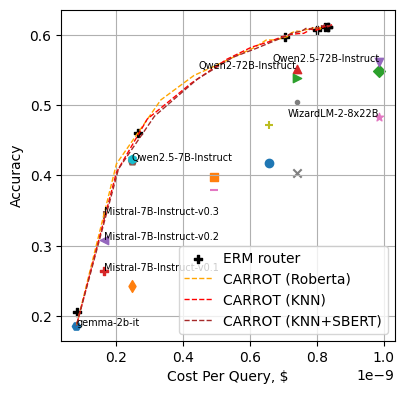

In [65]:
models = data['models']
fig, ax = plt.subplots(1, 1, figsize = (4.3, 4.3))

markers = ['o', 's', 'D', '^', 'v', 'p', '*', 'x', '+', 'h', 'H', 'd', '>', 'P', '<', '|', '_', '.', ',', '1']

for method in methods2:
    if 'lamb-' in method:
        if method.split('lamb-')[1]=='0':
            label = 'ERM router'
        else:
            label = ''
        ax.scatter(routers[method]['cost'], routers[method]['perf'], marker = markers[13], c='black', label = label)
    else:
        ax.errorbar(routers[method]['cost'], routers[method]['perf'], c=colors[method],
        linestyle='--', linewidth=1, alpha = 1, label = labels[method])

for i, txt in enumerate(models):

    x, y = C_test[:,i].mean(0), Y_test[:,i].mean(0)
    ax.scatter([x], [y], marker = markers[i])
    if i in set([3,4,6]):
        ax.annotate(models[i].split('/')[1], (x, y), size=7, horizontalalignment='right')
    if i in set([5,10,13,14,15]):
        ax.annotate(models[i].split('/')[1], (x, y), size=7)

ax.set_xlabel('Cost Per Query, \$')
ax.set_ylabel('Accuracy')
#ax.set_title('Open LLM Leaderboard v2')
# ax.plot(cost_router.mean(axis = 0), correctness_router.mean(axis = 0), linestyle='-', linewidth=2, label='router', alpha = 0.3)
ax.legend()
ax.grid(True)
plt.savefig(f'plots/hf-leaderboard2.pdf', bbox_inches='tight', dpi=400, transparent=False)
plt.show()

In [76]:
len(data['models'])

18